# RevIN for Univariate Time-Series Forecasting

The times series is a hourly air temperature measured by a synthetic weather station.

We will:

1. inspect a univariate physical time series;
2. identify two types of temporal distribution shift: **scale shift** and **shape/regime shift**;
3. convert the series into forecasting windows;
4. implement **Reversible Instance Normalization (RevIN)** by hand;
5. compare three simple regressors **with and without RevIN**:
   - Linear Regression,
   - Polynomial Regression,
   - Random Forest Regression;
6. visualize 24-hour forecasts and interpret the results.

> Reference: Kim et al., *Reversible Instance Normalization for Accurate Time-Series Forecasting against Distribution Shift*, ICLR 2022.

## 0. Learning objectives

By the end of the lab, you should be able to:

- define a **univariate time series**;
- explain why forecasting uses a **chronological split**;
- distinguish a change in **scale** from a change in **shape/regime**;
- explain why global normalization may be insufficient under temporal distribution shift;
- implement RevIN from first principles;
- compare forecasting models with and without RevIN.

# Environment setup

Before starting the practical session, create a dedicated Python environment for this notebook.

First; Open a Terminal

Move to the folder containing this notebook.

For example:

```bash
cd ~/Downloads

python3 -m venv .venv

then activate it 

source .venv/bin/activate

Then intstall pip: 

python -m pip install --upgrade pip

python -m pip install numpy pandas matplotlib scikit-learn ipykernel

rename it:

python -m ipykernel install --user \
    --name revintp \
    --display-name "RevInTP"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42

plt.rcParams.update({
    "figure.figsize": (12.5, 4.8),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
})

# 1. A physical univariate time series

A **univariate time series** contains one measured quantity at each time step:

\[
x_t \in \mathbb{R}.
\]

Here, \(x_t\) is the **air temperature in degrees Celsius** measured every hour by a weather station.

The synthetic signal contains physically plausible components:

- a daily heating/cooling cycle;
- slower synoptic weather variations;
- measurement noise;
- a progressive change in the amplitude of the daily cycle;
- a later change in the long-term regime and daily-cycle shape.

These changes make the series useful for studying **distribution shift**.

In [5]:
def generate_temperature_series(n_days=120, seed=11):
    rng = np.random.default_rng(seed)

    n_hours = n_days * 24
    t = np.arange(n_hours)
    day = t / 24.0
    hour = t % 24

    trend = 0.10 * np.minimum(day, 78)
    baseline = 6 + trend

    # Progressive increase in amplitude.
    scale_transition = 1 / (1 + np.exp(-(day - 62) / 2.5))
    amplitude = 4.0 * (1 + 0.85 * scale_transition)

    #24-hour cycle.
    daily_cycle = np.sin(2 * np.pi * hour / 24 - 1.1)

    # Later change in daily-cycle shape: a second harmonic appears.
    shape_transition = 1 / (1 + np.exp(-(day - 78) / 2.5))
    second_harmonic = 1.8 * shape_transition * np.sin(
        4 * np.pi * hour / 24 + 0.5
    )
    synoptic = (
        1.8 * np.sin(2 * np.pi * day / 8.5)
        + 0.6 * np.sin(2 * np.pi * day / 17)
    )

    # Measurement variability also increases slightly after the scale shift.
    noise_std = 0.55 * (1 + 0.50 * scale_transition)
    noise = rng.normal(0, noise_std, n_hours)

    temperature = (
        baseline
        + amplitude * daily_cycle
        + second_harmonic
        + synoptic
        + noise
    )

    index = pd.date_range("2025-01-01", periods=n_hours, freq="h")
    return pd.Series(temperature, index=index, name="temperature_C")


temperature = generate_temperature_series()
temperature.to_frame().head()

,temperature_C
2025-01-01 00:00:00,2.453977
2025-01-01 01:00:00,3.842935
2025-01-01 02:00:00,4.631176
2025-01-01 03:00:00,4.687873
2025-01-01 04:00:00,5.899807


# 2. Question 1: Can you find, by looking at the times series, the distribution shifts ?

Your first task is exploratory.

### A. Plot the complete temperature series

Use the time index on the x-axis and temperature on the y-axis.

### B. Look for a **scale shift**

A scale shift means that the local variability/amplitude changes. A useful diagnostic is a **7-day rolling standard deviation**.

### C. Look for a **shape/regime shift**

Here, the long-term evolution changes from an approximately increasing regime to a more stationary regime. The shape of the daily cycle also changes slightly.

Estimate the approximate period of:

- the scale shift;
- the shape/regime shift.

Then compare the average standardized 24-hour profile before and after the shift.

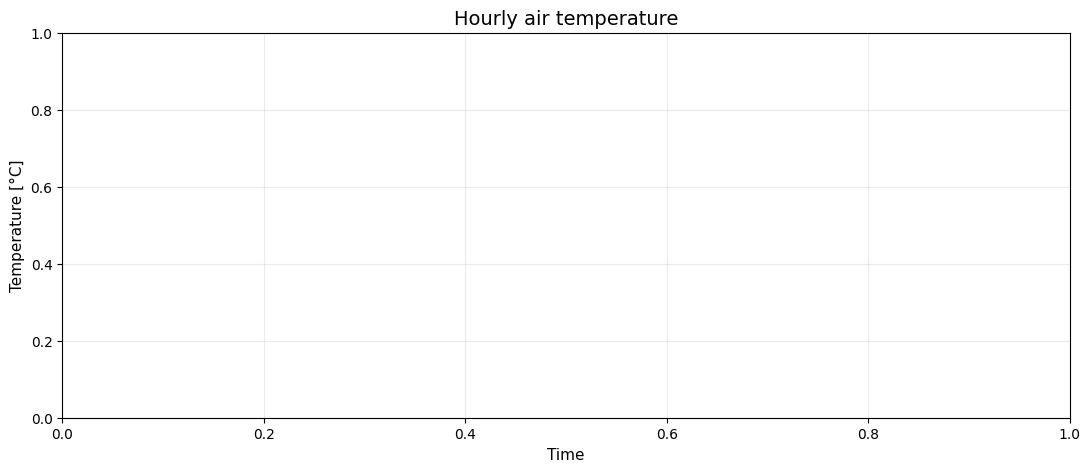

Estimated scale-shift period: ...
Estimated shape/regime-shift period: ...


In [ ]:
# QUESTION 1 — Complete this cell

# A. Plot the complete temperature series.
fig, ax = plt.subplots(figsize=(13, 5))

# TODO:
# ax.plot(...)

ax.set_title("Hourly air temperature")
ax.set_ylabel("Temperature [°C]")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
plt.show()


# B. Compute a 7-day rolling standard deviation.
# Hint: there are 24 * 7 hourly observations in one week.

# TODO:
# rolling_std = ...


# C. Give approximate transition periods after visual inspection.
scale_shift_period = "..."
shape_shift_period = "..."

print("Estimated scale-shift period:", scale_shift_period)
print("Estimated shape/regime-shift period:", shape_shift_period)

## Correction 1: Visual diagnosis of scale and shape changes

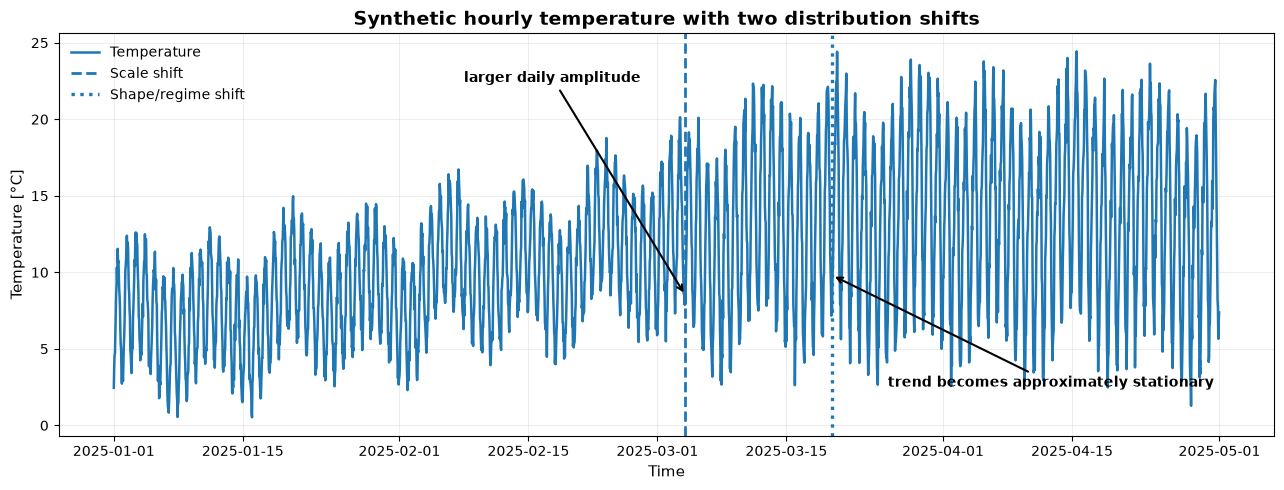

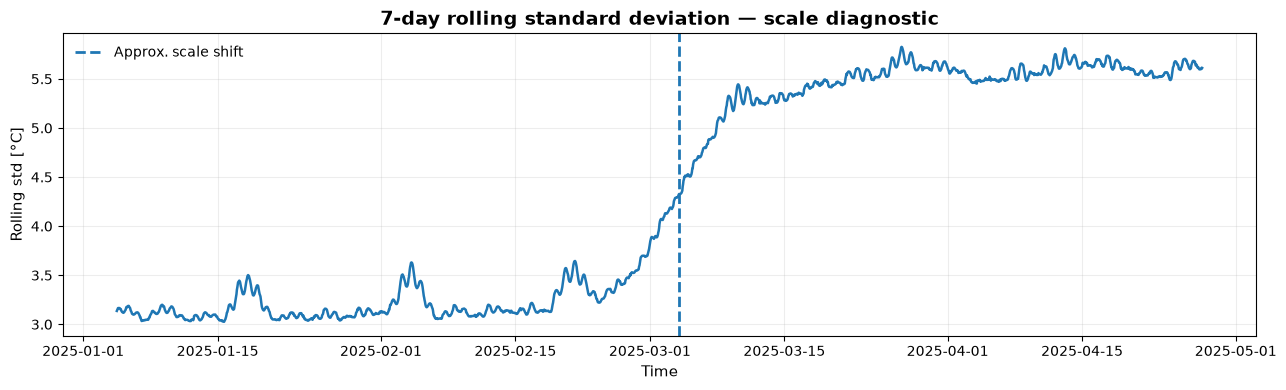

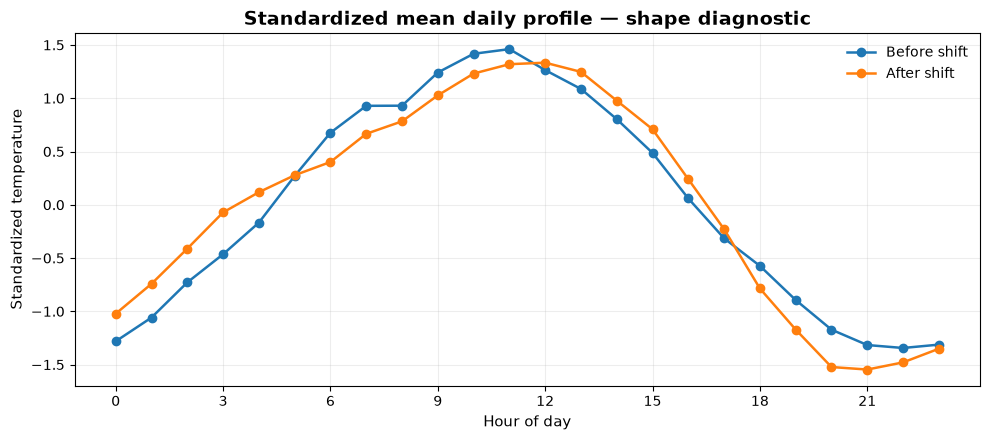

Approximate scale shift: early March 2025
Approximate shape/regime shift: around March 20, 2025


In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(temperature.index, temperature.values, label="Temperature")

scale_center = pd.Timestamp("2025-03-04")
shape_center = pd.Timestamp("2025-03-20")

ax.axvline(scale_center, linestyle="--", linewidth=2, label="Scale shift")
ax.axvline(shape_center, linestyle=":", linewidth=2.4, label="Shape/regime shift")

ax.annotate(
    "larger daily amplitude",
    xy=(scale_center, temperature.loc[scale_center]),
    xytext=(pd.Timestamp("2025-02-08"), temperature.max() - 2),
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
    fontweight="bold",
)

ax.annotate(
    "trend becomes approximately stationary",
    xy=(shape_center, temperature.loc[shape_center]),
    xytext=(pd.Timestamp("2025-03-26"), temperature.min() + 2),
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
    fontweight="bold",
)

ax.set_title("Synthetic hourly temperature with two distribution shifts", fontweight="bold")
ax.set_ylabel("Temperature [°C]")
ax.set_xlabel("Time")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


# --- Scale diagnostic: 7-day rolling standard deviation ---
rolling_std = temperature.rolling(24 * 7, center=True).std()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rolling_std.index, rolling_std.values)
ax.axvline(scale_center, linestyle="--", linewidth=2, label="Approx. scale shift")
ax.set_title("7-day rolling standard deviation — scale diagnostic", fontweight="bold")
ax.set_ylabel("Rolling std [°C]")
ax.set_xlabel("Time")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


# --- Shape diagnostic: compare normalized mean daily profiles ---
def mean_daily_profile(series, start, end):
    sample = series.loc[start:end].to_frame("temperature")
    sample["hour"] = sample.index.hour
    profile = sample.groupby("hour")["temperature"].mean()
    return profile

before = mean_daily_profile(temperature, "2025-02-10", "2025-02-24")
after = mean_daily_profile(temperature, "2025-04-05", "2025-04-19")

# Standardize each profile so that we compare SHAPE rather than level/scale.
before_z = (before - before.mean()) / before.std()
after_z = (after - after.mean()) / after.std()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(before_z.index, before_z.values, marker="o", label="Before shift")
ax.plot(after_z.index, after_z.values, marker="o", label="After shift")
ax.set_title("Standardized mean daily profile — shape diagnostic", fontweight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Standardized temperature")
ax.set_xticks(np.arange(0, 24, 3))
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Approximate scale shift: early March 2025")
print("Approximate shape/regime shift: around March 20, 2025")

### Interpretation

The two changes are deliberately different:

- **Scale shift:** the daily oscillations become larger, so the local variance increases.
- **Shape/regime shift:** the long-term trend changes from increasing to approximately stationary, and the normalized daily profile is no longer exactly the same.

This distinction matters for RevIN. RevIN directly removes local mean and scale differences, but it **cannot magically remove a true change in dynamics or shape**.

# 3. From a time series to a supervised forecasting problem

We predict the next 24 hours from the previous 48 hours.

For forecasting origin \(t\):

\[
X^{(i)} = [x_{t-48}, \dots, x_{t-1}]
\]

and

\[
y^{(i)} = [x_t, \dots, x_{t+23}].
\]

Thus:

- `X.shape = (n_samples, 48)`;
- `y.shape = (n_samples, 24)`.

## Question 2: Build the forecasting windows

Complete the two slices inside the loop.

In [8]:
LOOKBACK = 48 #windows context size
HORIZON = 24 #windows forecasting size

In [6]:



def make_windows_exercise(series, lookback=48, horizon=24):
    values = np.asarray(series, dtype=float)
    X, y = [], []

    for t in range(lookback, len(values) - horizon + 1):
        # TODO: previous `lookback` observations
        # X.append(...)

        # TODO: next `horizon` observations
        # y.append(...)
        pass

    # TODO: uncomment after completing the loop
    # return np.stack(X), np.stack(y)

## Correction 2

In [9]:
def make_windows(series, lookback=48, horizon=24):
    values = np.asarray(series, dtype=float)
    X, y = [], []

    for t in range(lookback, len(values) - horizon + 1):
        X.append(values[t - lookback:t])
        y.append(values[t:t + horizon])

    return np.stack(X), np.stack(y)


X, y = make_windows(temperature, LOOKBACK, HORIZON)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2809, 48)
y shape: (2809, 24)


## Chronological train / validation / test split

For forecasting, a random split would leak future regimes into the training set.

We therefore preserve time order:

\[
\text{train} \rightarrow \text{validation} \rightarrow \text{test}.
\]

The split is chosen so that training occurs mostly before the major regime changes, while the test set is mostly after them.

In [10]:
def chronological_split(X, y, train_frac=0.50, val_frac=0.15):
    n = len(X)
    i_train = int(train_frac * n)
    i_val = int((train_frac + val_frac) * n)

    return {
        "train": (X[:i_train], y[:i_train]),
        "val": (X[i_train:i_val], y[i_train:i_val]),
        "test": (X[i_val:], y[i_val:]),
    }, i_train, i_val


split, i_train, i_val = chronological_split(X, y)

# Map window indices back to approximate forecasting-origin timestamps.
origin_times = temperature.index[LOOKBACK:LOOKBACK + len(X)]
train_end_time = origin_times[i_train - 1]
test_start_time = origin_times[i_val]

print("Train ends around:", train_end_time)
print("Test starts around:", test_start_time)
print()

for name, (Xp, yp) in split.items():
    print(f"{name:>5}: X={Xp.shape}, y={yp.shape}")

Train ends around: 2025-03-02 11:00:00
Test starts around: 2025-03-20 01:00:00

train: X=(1404, 48), y=(1404, 24)
  val: X=(421, 48), y=(421, 24)
 test: X=(984, 48), y=(984, 24)


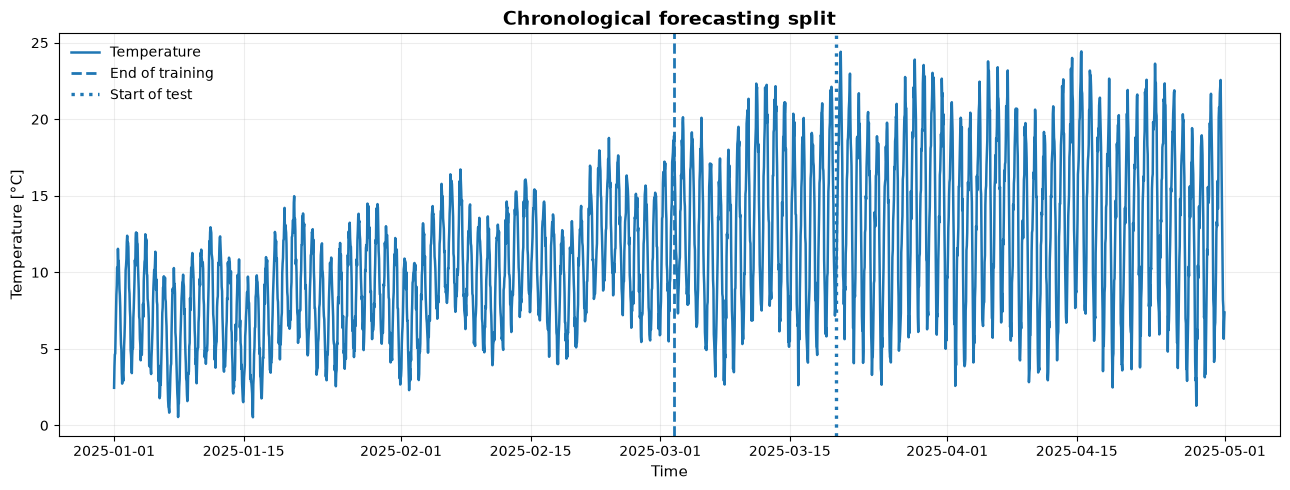

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(temperature.index, temperature.values, label="Temperature")
ax.axvline(train_end_time, linestyle="--", linewidth=2, label="End of training")
ax.axvline(test_start_time, linestyle=":", linewidth=2.4, label="Start of test")
ax.set_title("Chronological forecasting split", fontweight="bold")
ax.set_ylabel("Temperature [°C]")
ax.set_xlabel("Time")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# 4. RevIN: the core idea

A standard scaler estimates one global mean and variance from the training data.

RevIN instead normalizes **each forecasting window independently**.

For one input window \(X^{(i)} \in \mathbb{R}^{L}\):

\[
\mu_i = \frac{1}{L}\sum_{t=1}^{L} X_t^{(i)},
\]

\[
\sigma_i = \sqrt{\frac{1}{L}\sum_{t=1}^{L}(X_t^{(i)}-\mu_i)^2 + \varepsilon},
\]

\[
\widetilde{X}^{(i)} = \frac{X^{(i)}-\mu_i}{\sigma_i}.
\]

The target is expressed in the same local coordinates:

\[
\widetilde{y}^{(i)} = \frac{y^{(i)}-\mu_i}{\sigma_i}.
\]

After prediction, the transformation is reversed:

\[
\widehat{y}^{(i)} = \widehat{\widetilde{y}}^{(i)}\sigma_i + \mu_i.
\]

This is the key idea behind **reversible instance normalization**.

## Question 3 — Implement RevIN by hand

Complete the missing operations. In this univariate notebook, `X` has shape `(batch, lookback)` and `y` has shape `(batch, horizon)`.

In [ ]:
class RevINExercise:
    def __init__(self, eps=1e-5):
        self.eps = eps

    def normalize_input(self, X):
        # TODO 1: one mean per forecasting window
        mean = ...

        # TODO 2: one standard deviation per forecasting window
        std = ...

        # TODO 3: normalize the input window
        X_normalized = ...

        return X_normalized, mean, std

    def normalize_target(self, y, mean, std):
        # TODO 4: express the future target in the same local coordinates
        y_normalized = ...
        return y_normalized

    def denormalize_target(self, y_normalized, mean, std):
        # TODO 5: reverse the transformation
        y = ...
        return y

### Hints

- Compute statistics along the **time dimension**: `axis=1`.
- Keep shape `(batch, 1)` using `keepdims=True` so NumPy broadcasting works naturally.
- The same input-window `mean` and `std` are used for the future target and for the inverse transformation.

## Correction 3 — Reference NumPy implementation

In [ ]:
class RevIN:
    def __init__(self, eps=1e-5):
        self.eps = eps

    def normalize_input(self, X):
        mean = X.mean(axis=1, keepdims=True)
        std = X.std(axis=1, keepdims=True) + self.eps
        X_normalized = (X - mean) / std
        return X_normalized, mean, std

    def normalize_target(self, y, mean, std):
        return (y - mean) / std

    def denormalize_target(self, y_normalized, mean, std):
        return y_normalized * std + mean


# Check reversibility numerically.
revin = RevIN()
X_demo = X[:10]
y_demo = y[:10]

X_demo_n, mean_demo, std_demo = revin.normalize_input(X_demo)
y_demo_n = revin.normalize_target(y_demo, mean_demo, std_demo)
y_demo_back = revin.denormalize_target(y_demo_n, mean_demo, std_demo)

max_error = np.max(np.abs(y_demo_back - y_demo))
print("Maximum reconstruction error:", max_error)
assert np.allclose(y_demo_back, y_demo)

Maximum reconstruction error: 8.881784197001252e-16


## Visual intuition — the same windows before and after RevIN

We compare one window from the pre-shift regime and one from the post-shift regime.

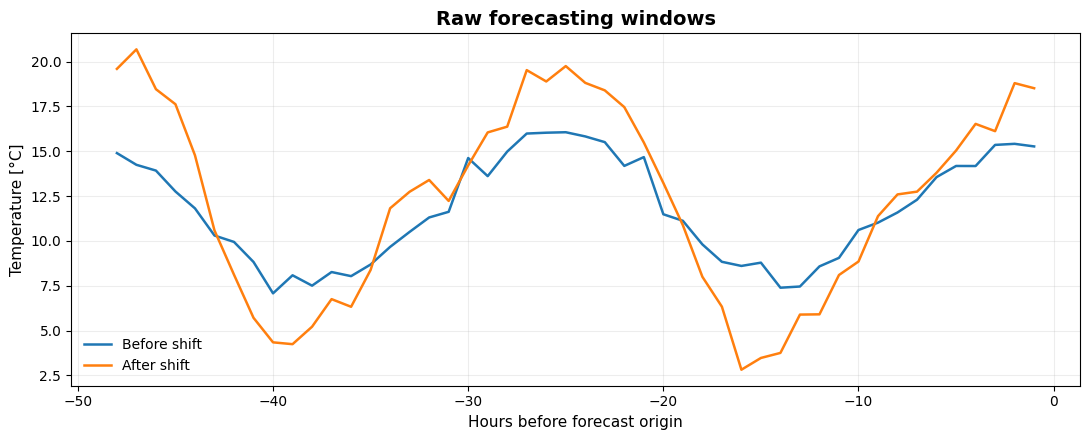

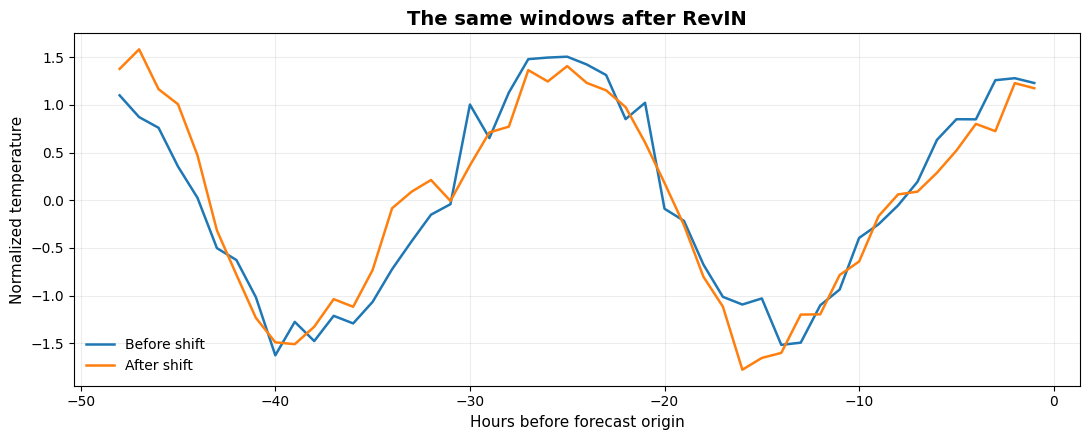

In [ ]:
pre_time = pd.Timestamp("2025-02-15 12:00")
post_time = pd.Timestamp("2025-04-10 12:00")

pre_idx = np.argmin(np.abs(origin_times - pre_time))
post_idx = np.argmin(np.abs(origin_times - post_time))

chosen = [(pre_idx, "Before shift"), (post_idx, "After shift")]

fig, ax = plt.subplots(figsize=(11, 4.5))
for idx, label in chosen:
    ax.plot(np.arange(-LOOKBACK, 0), X[idx], label=label)
ax.set_title("Raw forecasting windows", fontweight="bold")
ax.set_xlabel("Hours before forecast origin")
ax.set_ylabel("Temperature [°C]")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
for idx, label in chosen:
    window = X[idx:idx + 1]
    window_n, _, _ = revin.normalize_input(window)
    ax.plot(np.arange(-LOOKBACK, 0), window_n[0], label=label)
ax.set_title("The same windows after RevIN", fontweight="bold")
ax.set_xlabel("Hours before forecast origin")
ax.set_ylabel("Normalized temperature")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# 5. Forecasting models

We use three intentionally simple regression models.

### 1. Linear Regression

A linear mapping from the 48 lagged temperatures to the next 24 temperatures.

### 2. Polynomial Regression

We enrich the 48 lagged inputs with degree-2 polynomial interactions and use Ridge regression for numerical stability.

### 3. Random Forest Regressor

A nonlinear tree ensemble. Random forests are flexible, but tree predictions can struggle when test values lie outside the ranges seen during training.

The objective is **not** to find the best possible forecasting architecture. It is to isolate the effect of RevIN across different simple regressors.

## Question 4 — Instantiate the three models

Complete the model definitions using:

- `LinearRegression()`;
- `PolynomialFeatures(degree=2, include_bias=False)` followed by `Ridge(alpha=50.0)`;
- `RandomForestRegressor(...)`.

In [ ]:
# ============================================================
# QUESTION 4 — Complete this dictionary

MODEL_FACTORIES_EXERCISE = {
    "Linear Regression": lambda: ...,
    "Polynomial Regression": lambda: ...,
    "Random Forest": lambda: ...,
}

## Correction 4

In [ ]:
MODEL_FACTORIES = {
    "Linear Regression": lambda: LinearRegression(),

    "Polynomial Regression": lambda: make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        Ridge(alpha=50.0),
    ),

    "Random Forest": lambda: RandomForestRegressor(
        n_estimators=100,
        max_depth=14,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),
}

MODEL_FACTORIES

{'Linear Regression': <function __main__.<lambda>()>,
 'Polynomial Regression': <function __main__.<lambda>()>,
 'Random Forest': <function __main__.<lambda>()>}

# 6. Raw forecasting vs RevIN forecasting

For each model, we train two versions:

### Raw

\[
X \longrightarrow \text{model} \longrightarrow \widehat{y}
\]

### RevIN

\[
X
\longrightarrow
\widetilde{X}
\longrightarrow
\text{model}
\longrightarrow
\widehat{\widetilde{y}}
\longrightarrow
\widehat{y}
\]

Importantly, at test time the normalization statistics are computed **only from the observed input window**. No future target value is used.

In [ ]:
def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def run_experiment(split):
    X_train, y_train = split["train"]
    X_test, y_test = split["test"]

    revin = RevIN()

    # RevIN training coordinates.
    X_train_n, mean_train, std_train = revin.normalize_input(X_train)
    y_train_n = revin.normalize_target(y_train, mean_train, std_train)

    # RevIN test coordinates: statistics come ONLY from the input windows.
    X_test_n, mean_test, std_test = revin.normalize_input(X_test)

    rows = []
    predictions = {}

    for model_name, factory in MODEL_FACTORIES.items():
        # --------------------------
        # Raw model
        # --------------------------
        raw_model = factory()
        raw_model.fit(X_train, y_train)
        pred_raw = raw_model.predict(X_test)

        predictions[(model_name, "Raw")] = pred_raw
        rows.append({
            "Model": model_name,
            "Preprocessing": "Raw",
            **metrics(y_test, pred_raw),
        })

        # --------------------------
        # RevIN model
        # --------------------------
        revin_model = factory()
        revin_model.fit(X_train_n, y_train_n)

        pred_n = revin_model.predict(X_test_n)
        pred_revin = revin.denormalize_target(pred_n, mean_test, std_test)

        predictions[(model_name, "RevIN")] = pred_revin
        rows.append({
            "Model": model_name,
            "Preprocessing": "RevIN",
            **metrics(y_test, pred_revin),
        })

    return pd.DataFrame(rows), predictions, y_test


results, predictions, y_test = run_experiment(split)
results.round(3)

,Model,Preprocessing,MAE,RMSE
0,Linear Regression,Raw,1.380,1.687
1,Linear Regression,RevIN,1.366,1.669
2,Polynomial Regression,Raw,6.684,7.969
3,Polynomial Regression,RevIN,1.394,1.701
4,Random Forest,Raw,2.716,3.249
5,Random Forest,RevIN,1.455,1.780


In [ ]:
comparison = results.pivot(
    index="Model",
    columns="Preprocessing",
    values="MAE",
)

comparison["MAE improvement with RevIN [%]"] = (
    100 * (comparison["Raw"] - comparison["RevIN"]) / comparison["Raw"]
)

comparison.round(2)

Preprocessing,Raw,RevIN,MAE improvement with RevIN [%]
Model,,,
Linear Regression,1.38,1.37,1.01
Polynomial Regression,6.68,1.39,79.14
Random Forest,2.72,1.45,46.43


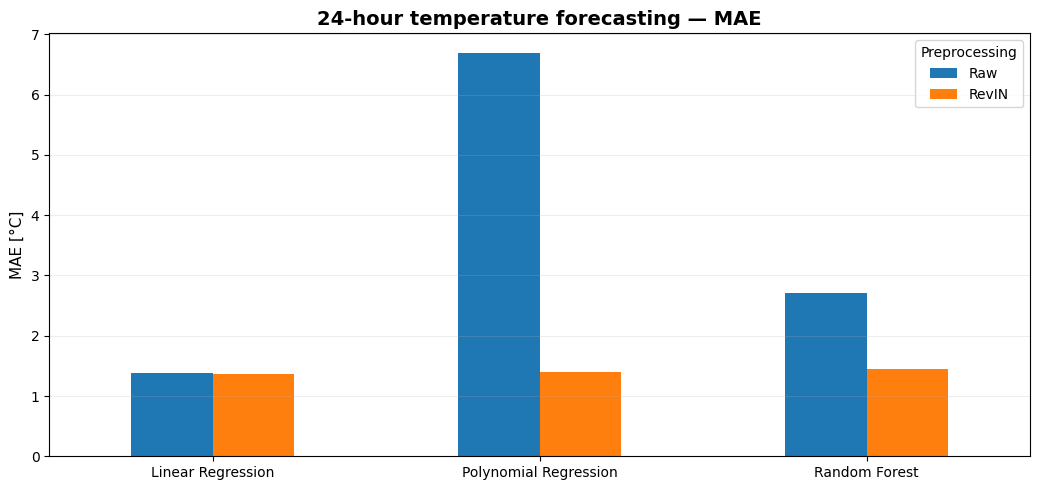

In [ ]:
ax = results.pivot(
    index="Model",
    columns="Preprocessing",
    values="MAE",
).plot(kind="bar", figsize=(10.5, 5))

ax.set_title("24-hour temperature forecasting — MAE", fontweight="bold")
ax.set_ylabel("MAE [°C]")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.22)
plt.tight_layout()
plt.show()

# 7. Forecast visualizations

The model predicts all 24 future hours at every forecasting origin.

We inspect the results in two complementary ways:

1. a rolling **one-step-ahead** view across many test origins;
2. one complete **24-hour forecast**.

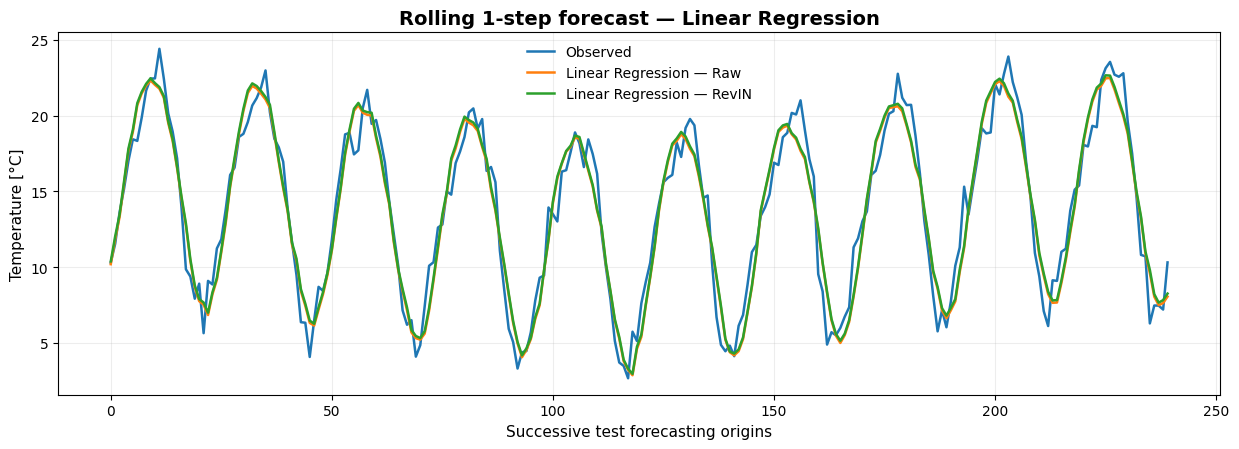

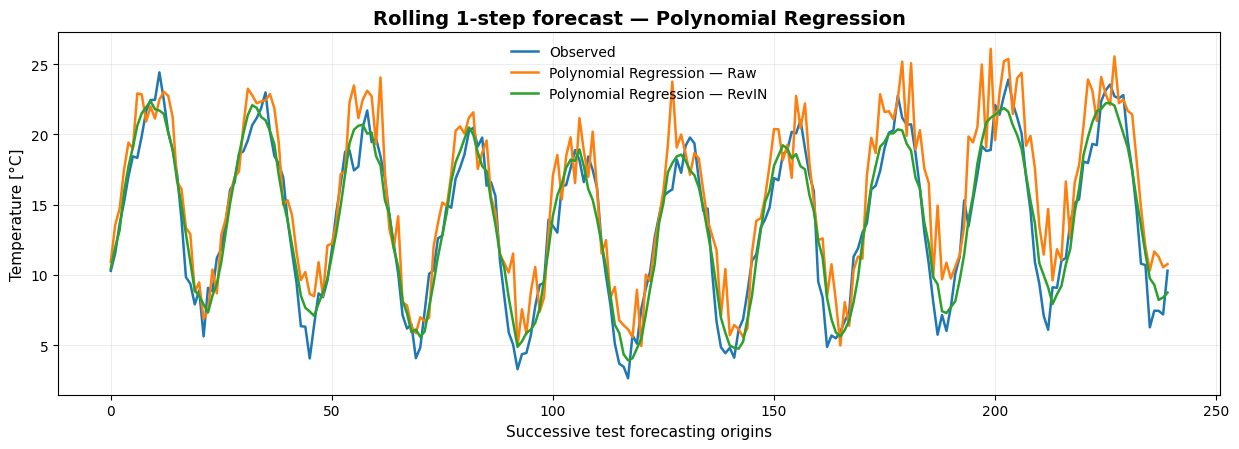

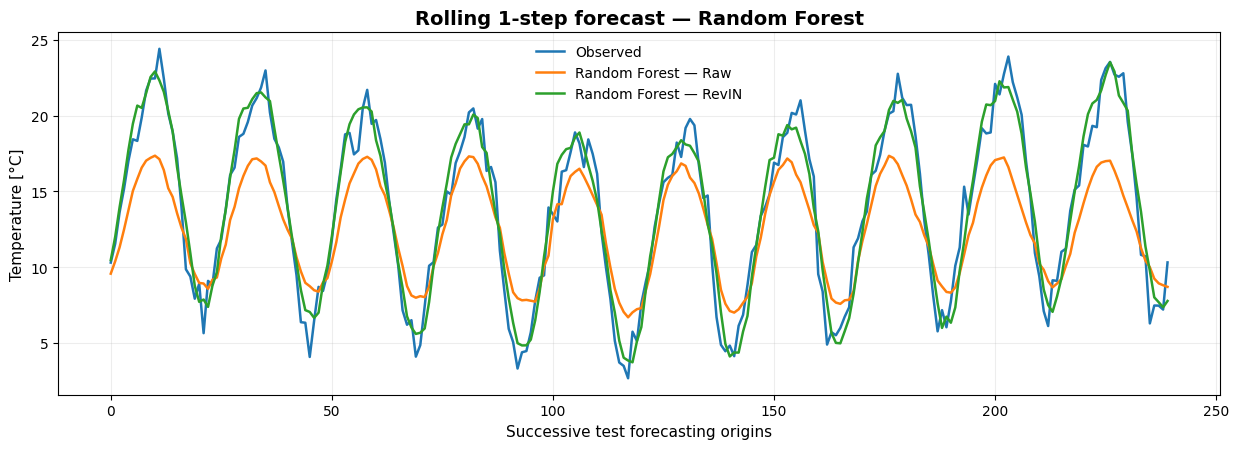

In [ ]:
# Rolling first-step forecast over approximately 10 days.
n_show = min(24 * 10, len(y_test))

for model_name in MODEL_FACTORIES:
    fig, ax = plt.subplots(figsize=(12.5, 4.6))

    ax.plot(y_test[:n_show, 0], label="Observed")
    ax.plot(
        predictions[(model_name, "Raw")][:n_show, 0],
        label=f"{model_name} — Raw",
    )
    ax.plot(
        predictions[(model_name, "RevIN")][:n_show, 0],
        label=f"{model_name} — RevIN",
    )

    ax.set_title(f"Rolling 1-step forecast — {model_name}", fontweight="bold")
    ax.set_xlabel("Successive test forecasting origins")
    ax.set_ylabel("Temperature [°C]")
    ax.grid(alpha=0.22)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

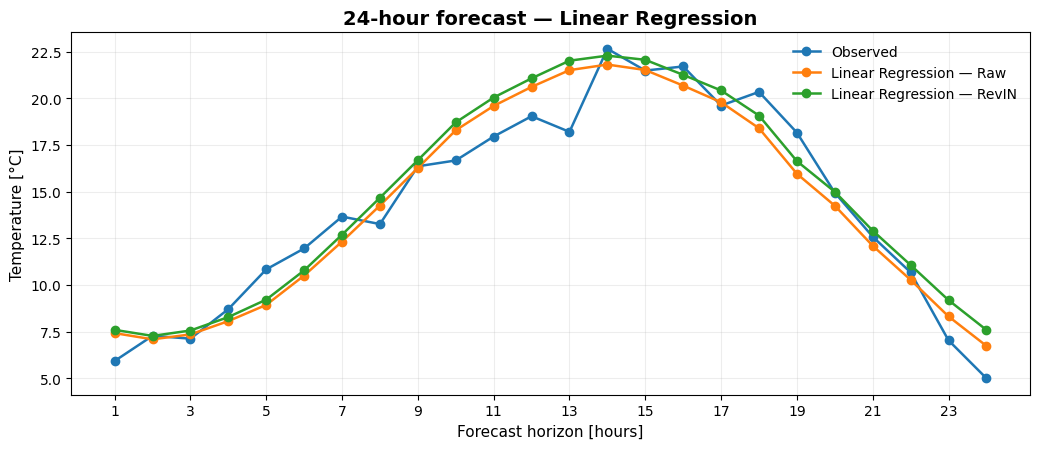

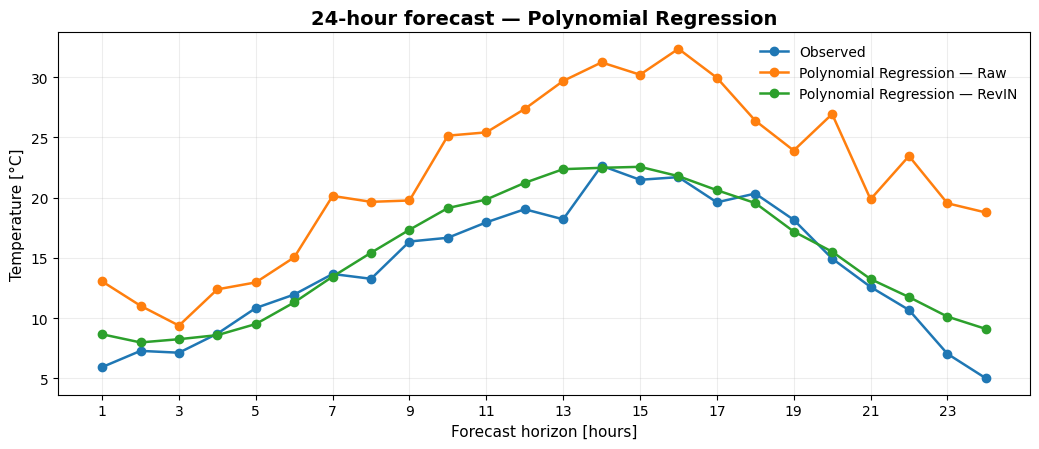

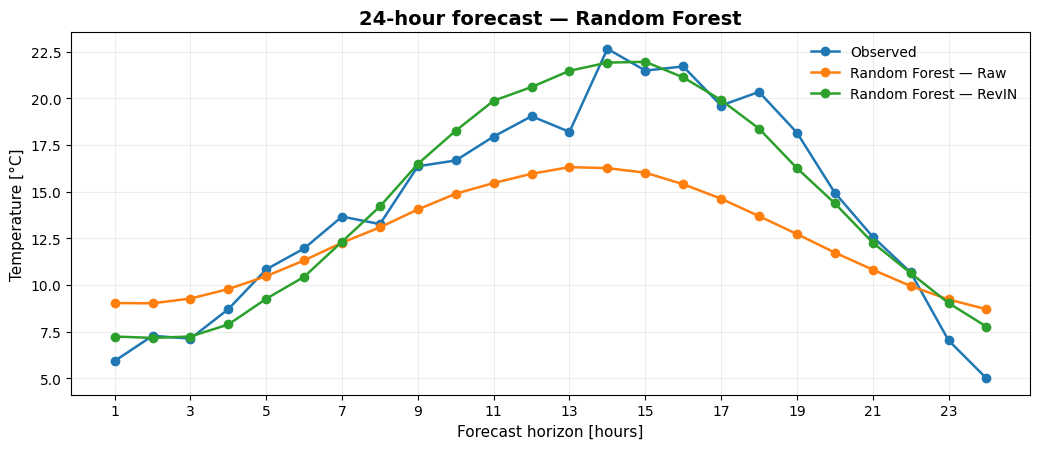

In [ ]:
# A complete 24-hour forecast in the shifted test regime.
forecast_id = min(260, len(y_test) - 1)
hours_ahead = np.arange(1, HORIZON + 1)

for model_name in MODEL_FACTORIES:
    fig, ax = plt.subplots(figsize=(10.5, 4.6))

    ax.plot(hours_ahead, y_test[forecast_id], marker="o", label="Observed")
    ax.plot(
        hours_ahead,
        predictions[(model_name, "Raw")][forecast_id],
        marker="o",
        label=f"{model_name} — Raw",
    )
    ax.plot(
        hours_ahead,
        predictions[(model_name, "RevIN")][forecast_id],
        marker="o",
        label=f"{model_name} — RevIN",
    )

    ax.set_title(f"24-hour forecast — {model_name}", fontweight="bold")
    ax.set_xlabel("Forecast horizon [hours]")
    ax.set_ylabel("Temperature [°C]")
    ax.set_xticks(np.arange(1, HORIZON + 1, 2))
    ax.grid(alpha=0.22)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# 9. Take-home message

RevIN can be summarized as:

\[
\boxed{
\text{local normalization}
\rightarrow
\text{forecast}
\rightarrow
\text{restore the local scale}
}
\]

The important point is not simply that the data are standardized. The normalization is:

- **instance-wise**: every forecasting window gets its own statistics;
- **temporal**: the statistics come from the currently observed past;
- **reversible**: the original physical scale is restored after prediction.

This makes RevIN particularly useful when the future differs from the training data mainly through local **level and scale changes**.

A true **shape/regime change** is harder: normalization cannot replace a forecasting model capable of learning new dynamics.

## ETT datasets

We now use the Electricity Transformer Temperature (ETT) benchmark.

The four datasets are:

- `ETTh1`, `ETTh2`: hourly observations;
- `ETTm1`, `ETTm2`: observations every 15 minutes.

In this practical session, we consider the **univariate forecasting setting**
and predict only the oil temperature:

$$
y_t = \mathrm{OT}_t.
$$

We fix the input lookback to

$$
L = 96
$$

observations.

For long-term forecasting, the classical ETT benchmark commonly considers

$$
H \in \{96, 192, 336, 720\}.
$$

For a simpler short-term forecasting experiment, we will forecast the next
24 physical hours.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET = "ETTh1"      # "ETTh1", "ETTh2", "ETTm1", "ETTm2"
TARGET = "OT"

LOOKBACK = 96          # fixed input window

FORECASTING_TASK = "short"   # "short" or "long"

LONG_HORIZONS = [96, 192, 336, 720]

LONG_HORIZON = 336

df = pd.read_csv(
    chemin_vers_le_fichier_csv,
    parse_dates=["date"]
)

df = df.set_index("date").sort_index()

print(f"Dataset: {DATASET}")
print(f"Shape:   {df.shape}")
print(f"Columns: {list(df.columns)}")

display(df.head())

In [ ]:
if DATASET.startswith("ETTh"):
    sampling_minutes = 60
elif DATASET.startswith("ETTm"):
    sampling_minutes = 15
else:
    raise ValueError("Unknown ETT dataset.")


if FORECASTING_TASK == "short":

    # Forecast the next 24 physical hours
    PRED_LEN = int(24 * 60 / sampling_minutes)

elif FORECASTING_TASK == "long":

    # Classical ETT long-term forecasting setting
    PRED_LEN = LONG_HORIZON

else:
    raise ValueError(
        "FORECASTING_TASK must be 'short' or 'long'."
    )


print(f"Sampling interval : {sampling_minutes} minutes")
print(f"Lookback          : {LOOKBACK} observations")
print(f"Forecast horizon  : {PRED_LEN} observations")

print(
    f"Lookback duration : "
    f"{LOOKBACK * sampling_minutes / 60:.1f} hours"
)

print(
    f"Forecast duration : "
    f"{PRED_LEN * sampling_minutes / 60:.1f} hours"
)

In [ ]:

series = df[TARGET].astype(float)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    series.index,
    series.values,
    linewidth=1.0
)

ax.set_title(
    f"{DATASET} — Oil Temperature",
    fontweight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("Oil Temperature")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:

def make_windows(series, lookback, horizon):

    values = np.asarray(series, dtype=np.float32)

    X, y = [], []

    for t in range(
        lookback,
        len(values) - horizon + 1
    ):

        X.append(
            values[t - lookback:t]
        )

        y.append(
            values[t:t + horizon]
        )

    return np.stack(X), np.stack(y)


X, y = make_windows(
    series,
    lookback=LOOKBACK,
    horizon=PRED_LEN
)

print("X shape:", X.shape)
print("y shape:", y.shape)

# References

- Kim, T., Kim, J., Tae, Y., Park, C., Choi, J.-H., & Choo, J. **Reversible Instance Normalization for Accurate Time-Series Forecasting against Distribution Shift.** ICLR 2022.
- Official implementation: `https://github.com/ts-kim/RevIN`
- OpenReview: `https://openreview.net/forum?id=cGDAkQo1C0p`